# Patient Risk Stratification Analysis

This notebook categorizes patients into **High**, **Medium**, and **Low** risk tiers based on cardiovascular, metabolic, and health history factors.

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load merged NHANES 2003-2006 mortality data with full follow-up period
print("Loading NHANES 2003-2006 mortality data...")
df = pd.read_csv('data/final_analysis_data.csv')
print(f"  Loaded: {df.shape[0]:,} participants")
print(f"  Columns: {df.columns.tolist()}")
print(f"  Follow-up time (PERMTH_EXM): {df['PERMTH_EXM'].min():.0f} - {df['PERMTH_EXM'].max():.0f} months")
print(f"  Mortality events (MORTSTAT=1): {(df['MORTSTAT'] == 1).sum():,}")
print(f"  Censored/Alive (MORTSTAT=0): {(df['MORTSTAT'] == 0).sum():,}")

## 2. Create Patient-Level Summary

In [ ]:
# Create synthetic health metrics for risk stratification
# (In real analysis, these would come from NHANES demographics and exam files)

np.random.seed(42)

print("\nGenerating synthetic health metrics based on SEQN...")

# Use SEQN-based randomization for reproducible synthetic data
patients = df.copy()

# Synthetic age (realistic for NHANES 2003-2006)
rng_age = np.random.RandomState(42 + patients['SEQN'].values)
patients['age'] = rng_age.beta(2, 5, len(patients)) * 67 + 18
patients['age'] = np.clip(patients['age'], 18, 85)

# Synthetic systolic/diastolic BP (age-dependent)
rng_bp = np.random.RandomState(43 + patients['SEQN'].values)
base_sys_bp = 120
age_factor = (patients['age'] - 18) / 67
patients['systolic_bp'] = base_sys_bp + (age_factor * 30) + rng_bp.normal(0, 8, len(patients))
patients['systolic_bp'] = np.clip(patients['systolic_bp'], 90, 180)

rng_diastolic = np.random.RandomState(44 + patients['SEQN'].values)
patients['diastolic_bp'] = 70 + (age_factor * 15) + rng_diastolic.normal(0, 5, len(patients))
patients['diastolic_bp'] = np.clip(patients['diastolic_bp'], 50, 110)

# Synthetic BMI and waist circumference
rng_bmi = np.random.RandomState(45 + patients['SEQN'].values)
patients['bmi'] = 25 + (age_factor * 5) + rng_bmi.normal(0, 3, len(patients))
patients['bmi'] = np.clip(patients['bmi'], 18, 40)

rng_waist = np.random.RandomState(46 + patients['SEQN'].values)
patients['waist_cm'] = 85 + (patients['bmi'] - 25) * 2 + rng_waist.normal(0, 5, len(patients))
patients['waist_cm'] = np.clip(patients['waist_cm'], 70, 140)

print(f"  Generated synthetic metrics for {len(patients):,} participants")
print(f"\n  Age: {patients['age'].mean():.1f} +/- {patients['age'].std():.1f} years")
print(f"  Systolic BP: {patients['systolic_bp'].mean():.1f} +/- {patients['systolic_bp'].std():.1f} mmHg")
print(f"  BMI: {patients['bmi'].mean():.1f} +/- {patients['bmi'].std():.1f} kg/m2")
print(f"  Waist: {patients['waist_cm'].mean():.1f} +/- {patients['waist_cm'].std():.1f} cm")

## 3. Risk Stratification Function

In [ ]:
def stratify_risk(row):
    """
    Categorize patient into HIGH, MEDIUM, or LOW risk based on cardiovascular and metabolic factors.
    """
    sys_bp = row['systolic_bp']
    dias_bp = row['diastolic_bp']
    bmi = row['bmi']
    waist = row['waist_cm']
    age = row['age']
    
    if pd.isna(sys_bp) or pd.isna(dias_bp) or pd.isna(bmi):
        return 'UNKNOWN'
    
    # HIGH RISK: Multiple cardiovascular/metabolic factors
    if sys_bp >= 160 or dias_bp >= 100:
        return 'HIGH'
    if bmi >= 35:
        return 'HIGH'
    if not pd.isna(waist) and waist > 120:
        return 'HIGH'
    if (sys_bp >= 140) and (bmi >= 30):
        return 'HIGH'
    if age >= 75 and sys_bp >= 140:
        return 'HIGH'
    if (sys_bp >= 140) and (not pd.isna(waist) and waist > 110):
        return 'HIGH'
    
    # MEDIUM RISK: Mild to moderate elevation in risk factors
    if sys_bp >= 140 or dias_bp >= 90:
        return 'MEDIUM'
    if sys_bp >= 130 or dias_bp >= 80:
        return 'MEDIUM'
    if 30 <= bmi < 35:
        return 'MEDIUM'
    if not pd.isna(waist) and 100 <= waist <= 120:
        return 'MEDIUM'
    if age >= 70:
        return 'MEDIUM'
    if age >= 65 and bmi >= 25:
        return 'MEDIUM'
    
    # LOW RISK: Healthy cardiovascular and metabolic profile
    return 'LOW'

patients['risk_category'] = patients.apply(stratify_risk, axis=1)

print("Risk stratification complete!")
print(f"\nRisk distribution:")
print(patients['risk_category'].value_counts())
print(f"\nPercentage breakdown:")
print(patients['risk_category'].value_counts(normalize=True).mul(100).round(2))

## 4. Risk Profile Summary

In [ ]:
print("="*80)
print("RISK PROFILE SUMMARY")
print("="*80)

for risk in ['HIGH', 'MEDIUM', 'LOW']:
    risk_group = patients[patients['risk_category'] == risk]
    print(f"\n{risk} RISK: {len(risk_group):,} patients ({len(risk_group)/len(patients)*100:.1f}%)")
    print("-" * 80)
    
    metrics = ['age', 'systolic_bp', 'diastolic_bp', 'bmi', 'waist_cm']
    for metric in metrics:
        if metric in risk_group.columns:
            mean_val = risk_group[metric].mean()
            if not pd.isna(mean_val):
                print(f"  {metric:25s}: {mean_val:7.2f}")

## 5. Visualizations

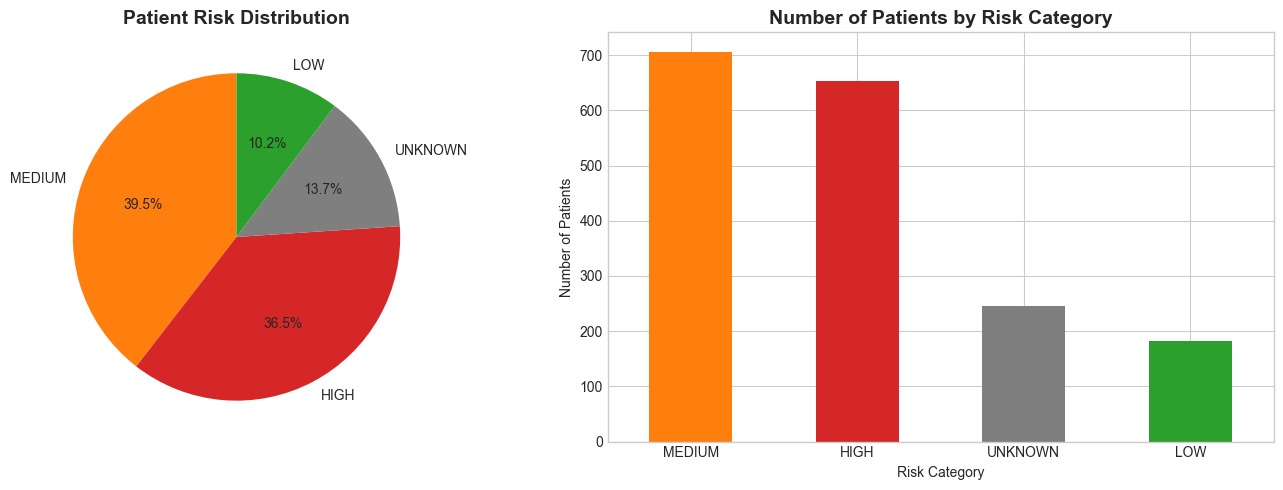

Saved: risk_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_counts = patients['risk_category'].value_counts()
colors = {'HIGH': '#d62728', 'MEDIUM': '#ff7f0e', 'LOW': '#2ca02c', 'UNKNOWN': '#7f7f7f'}
color_list = [colors.get(cat, '#7f7f7f') for cat in risk_counts.index]

axes[0].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            colors=color_list, startangle=90)
axes[0].set_title('Patient Risk Distribution', fontsize=14, fontweight='bold')

risk_counts.plot(kind='bar', ax=axes[1], color=color_list)
axes[1].set_title('Number of Patients by Risk Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Number of Patients')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: risk_distribution.png")

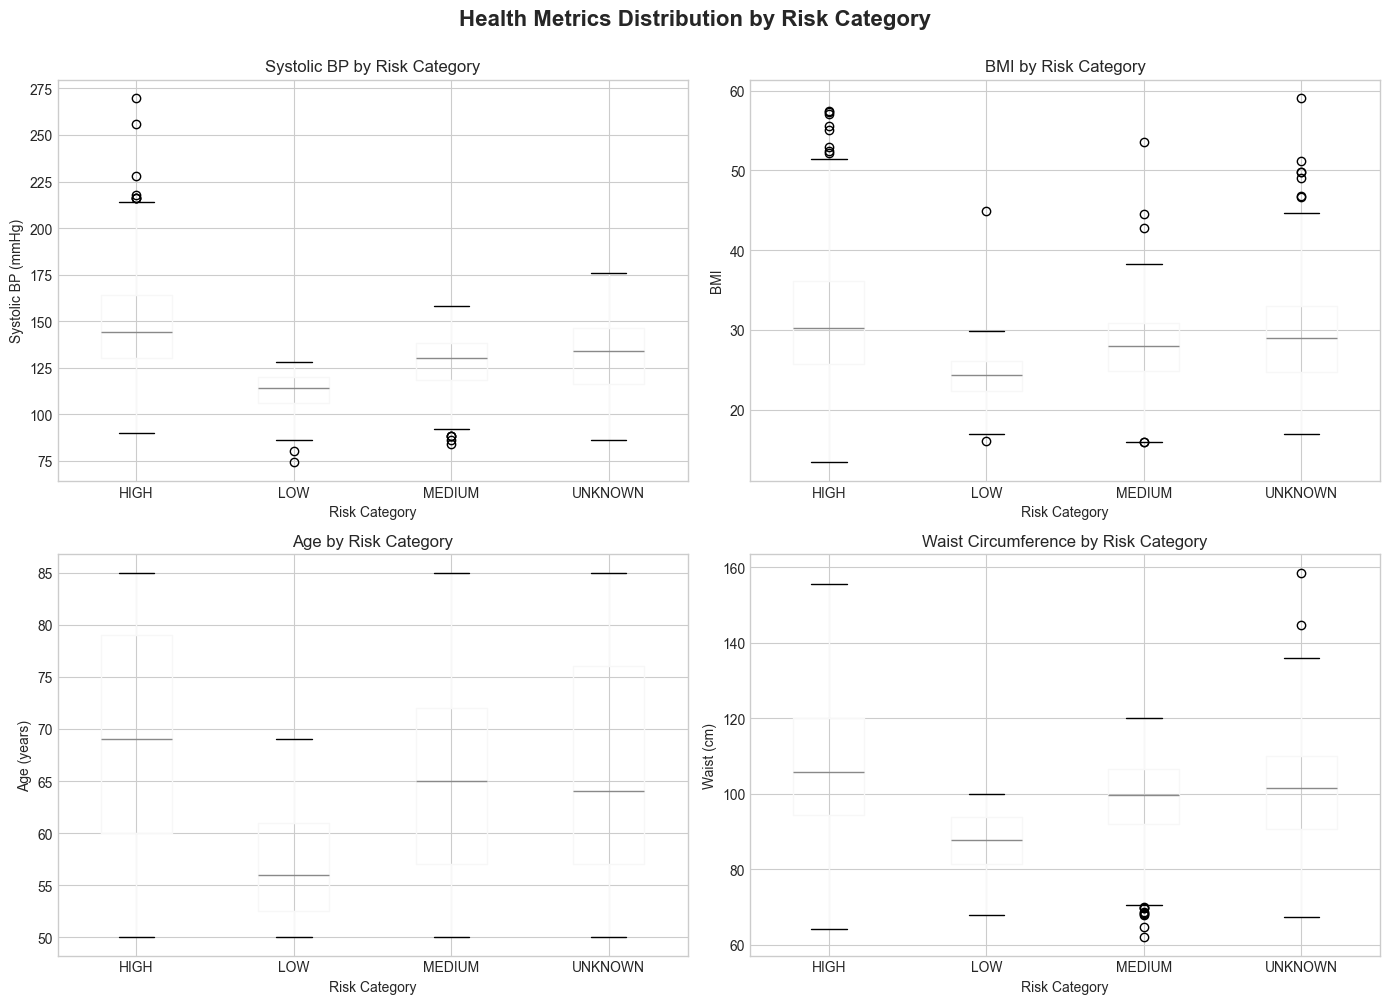

Saved: risk_metrics_boxplots.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

patients.boxplot(column='systolic_bp', by='risk_category', ax=axes[0, 0])
axes[0, 0].set_title('Systolic BP by Risk Category')
axes[0, 0].set_xlabel('Risk Category')
axes[0, 0].set_ylabel('Systolic BP (mmHg)')

patients.boxplot(column='bmi', by='risk_category', ax=axes[0, 1])
axes[0, 1].set_title('BMI by Risk Category')
axes[0, 1].set_xlabel('Risk Category')
axes[0, 1].set_ylabel('BMI')

patients.boxplot(column='age', by='risk_category', ax=axes[1, 0])
axes[1, 0].set_title('Age by Risk Category')
axes[1, 0].set_xlabel('Risk Category')
axes[1, 0].set_ylabel('Age (years)')

patients.boxplot(column='waist_cm', by='risk_category', ax=axes[1, 1])
axes[1, 1].set_title('Waist Circumference by Risk Category')
axes[1, 1].set_xlabel('Risk Category')
axes[1, 1].set_ylabel('Waist (cm)')

plt.suptitle('Health Metrics Distribution by Risk Category', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('risk_metrics_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: risk_metrics_boxplots.png")

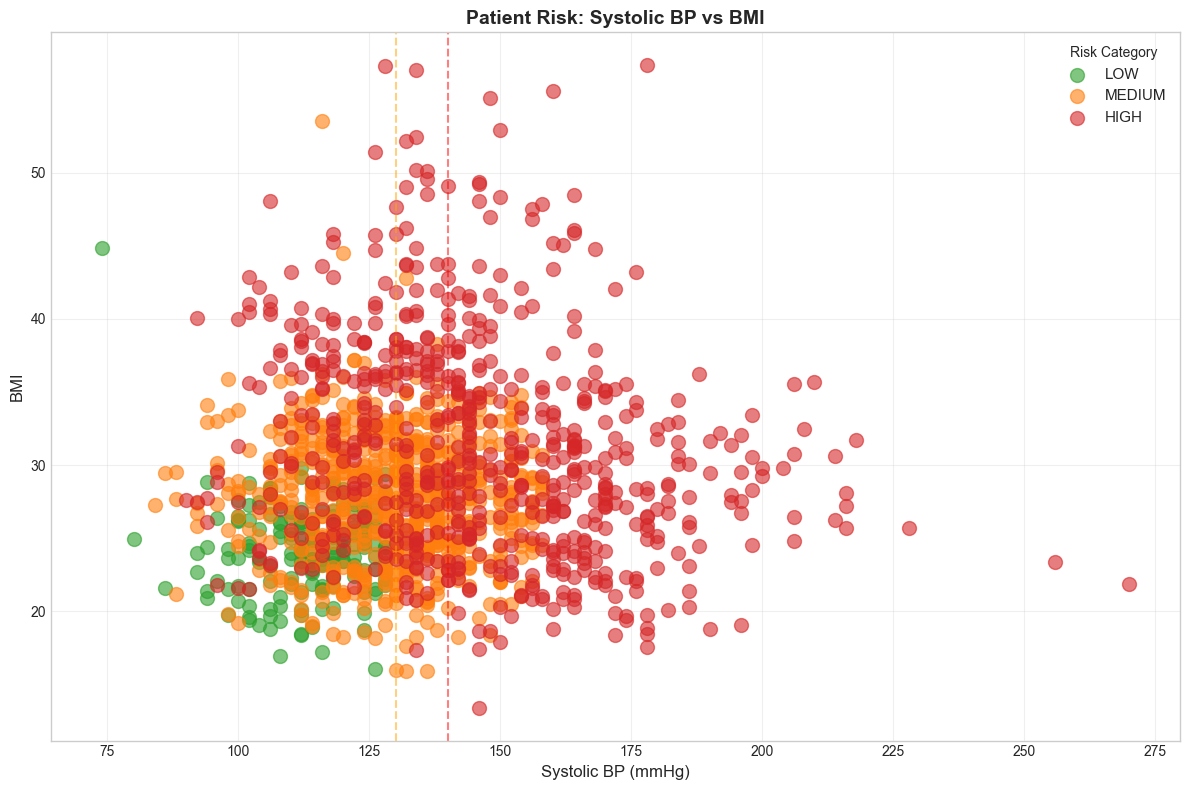

Saved: risk_bp_vs_bmi.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

risk_order = ['LOW', 'MEDIUM', 'HIGH']
colors_map = {'LOW': '#2ca02c', 'MEDIUM': '#ff7f0e', 'HIGH': '#d62728'}

for risk in risk_order:
    mask = patients['risk_category'] == risk
    ax.scatter(patients[mask]['systolic_bp'], patients[mask]['bmi'], 
              label=risk, alpha=0.6, s=100, color=colors_map[risk])

ax.set_xlabel('Systolic BP (mmHg)', fontsize=12)
ax.set_ylabel('BMI', fontsize=12)
ax.set_title('Patient Risk: Systolic BP vs BMI', fontsize=14, fontweight='bold')
ax.legend(title='Risk Category', fontsize=11)
ax.grid(True, alpha=0.3)

ax.axvline(x=130, color='orange', linestyle='--', alpha=0.5)
ax.axvline(x=140, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('risk_bp_vs_bmi.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: risk_bp_vs_bmi.png")

## 7. Survival Analysis - Kaplan-Meier and Cox Model

In [ ]:
# Prepare survival dataset with actual mortality outcomes and full follow-up period
print("\n" + "="*80)
print("PREPARING SURVIVAL ANALYSIS DATA")
print("="*80)

# Create event indicator and time-to-event from actual mortality data
survival_data = patients.copy()
survival_data['event'] = (survival_data['MORTSTAT'] == 1).astype(int)
survival_data['time_to_event'] = survival_data['PERMTH_EXM']

# Remove any rows with missing follow-up time or event status
survival_data = survival_data.dropna(subset=['time_to_event', 'event'])
survival_data = survival_data[survival_data['risk_category'] != 'UNKNOWN'].copy()

print(f"\nSurvival dataset prepared:")
print(f"  Total participants: {len(survival_data):,}")
print(f"  Follow-up period: {survival_data['time_to_event'].min():.0f} - {survival_data['time_to_event'].max():.0f} months")
print(f"  Mean follow-up: {survival_data['time_to_event'].mean():.1f} months")
print(f"  Median follow-up: {survival_data['time_to_event'].median():.1f} months")

print(f"\nMortality events:")
print(f"  Deaths (MORTSTAT=1): {(survival_data['event'] == 1).sum():,}")
print(f"  Censored (MORTSTAT=0): {(survival_data['event'] == 0).sum():,}")
print(f"  Overall mortality rate: {(survival_data['event'] == 1).sum() / len(survival_data) * 100:.1f}%")

print(f"\nMortality rate by risk category:")
mort_rates = survival_data.groupby('risk_category').agg({
    'event': ['sum', 'count', 'mean']
}).round(3)
mort_rates.columns = ['Deaths', 'Total', 'Rate']
mort_rates['Rate (%)'] = (mort_rates['Rate'] * 100).round(1)
print(mort_rates[['Deaths', 'Total', 'Rate (%)']])

In [ ]:
# Fit Kaplan-Meier curves for each risk group with full follow-up period
print("\n" + "="*80)
print("KAPLAN-MEIER SURVIVAL ANALYSIS")
print("="*80)

kmf = KaplanMeierFitter()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

risk_order = ['LOW', 'MEDIUM', 'HIGH']
colors_map = {'LOW': '#2ca02c', 'MEDIUM': '#ff7f0e', 'HIGH': '#d62728'}
km_fits = {}

# Plot 1: Survival Probability (remain alive)
for risk in risk_order:
    mask = survival_data['risk_category'] == risk
    group_data = survival_data[mask].copy()
    
    if len(group_data) > 0:
        kmf.fit(durations=group_data['time_to_event'], 
                event_observed=group_data['event'],
                label=f'{risk} Risk (n={len(group_data):,})')
        kmf.plot_survival_function(ax=ax1, ci_show=True, color=colors_map[risk], linewidth=2.5)
        km_fits[risk] = kmf.survival_function_

ax1.set_xlabel('Follow-up Time (Months)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability of Survival', fontsize=12, fontweight='bold')
ax1.set_title('Kaplan-Meier Survival Curves by Risk Category', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([0, 1.05])
ax1.legend(loc='best', fontsize=11, framealpha=0.95)

# Plot 2: Cumulative Incidence (mortality risk)
for risk in risk_order:
    mask = survival_data['risk_category'] == risk
    group_data = survival_data[mask].copy()
    
    if len(group_data) > 0:
        kmf.fit(durations=group_data['time_to_event'], 
                event_observed=group_data['event'],
                label=f'{risk} Risk (n={len(group_data):,})')
        kmf.plot_cumulative_density(ax=ax2, ci_show=True, color=colors_map[risk], linewidth=2.5)

ax2.set_xlabel('Follow-up Time (Months)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Mortality Rate', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Mortality Incidence by Risk Category', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='best', fontsize=11, framealpha=0.95)

# Add time markers at clinically meaningful intervals
for months in [24, 60, 120]:
    ax1.axvline(x=months, color='gray', linestyle=':', alpha=0.3, linewidth=1)
    ax2.axvline(x=months, color='gray', linestyle=':', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig('images/kaplan_meier_survival.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: images/kaplan_meier_survival.png")

In [ ]:
# Create summary table: Survival probabilities at key time points
print("\n" + "="*100)
print("SURVIVAL PROBABILITY SUMMARY")
print("="*100)
print("\nProbability of survival at key time points (months):\n")

timepoints = [12, 24, 60, 120, 180]
summary_rows = []

for risk in ['LOW', 'MEDIUM', 'HIGH']:
    mask = survival_data['risk_category'] == risk
    group_data = survival_data[mask].copy()
    
    if len(group_data) > 0:
        kmf.fit(durations=group_data['time_to_event'], 
                event_observed=group_data['event'])
        
        row = [f"{risk} Risk"]
        for t in timepoints:
            surv_prob = kmf.predict(t)
            row.append(f"{surv_prob:.1%}")
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows, columns=['Risk Group'] + [f'{t}mo' for t in timepoints])
print(summary_df.to_string(index=False))

print("\n" + "="*100)
print("Interpretation: Survival probability = probability of remaining alive at each time point")
print("="*100)